#Assignment 1: Perform EDA on raw_house_data.csv
###Author: Poorvi Raut

###Importing necessary python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime  # Import the datetime module

###Loading the csv file

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/DS_Assignment1/raw_house_data - raw_house_data.csv')

In [ ]:
#Display basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MLS               5000 non-null   int64  
 1   sold_price        5000 non-null   float64
 2   zipcode           5000 non-null   int64  
 3   longitude         5000 non-null   float64
 4   latitude          5000 non-null   float64
 5   lot_acres         4990 non-null   float64
 6   taxes             5000 non-null   float64
 7   year_built        5000 non-null   int64  
 8   bedrooms          5000 non-null   int64  
 9   bathrooms         4994 non-null   float64
 10  sqrt_ft           4944 non-null   float64
 11  garage            4993 non-null   float64
 12  kitchen_features  4967 non-null   object 
 13  fireplaces        4975 non-null   float64
 14  floor_covering    4999 non-null   object 
 15  HOA               4438 non-null   object 
dtypes: float64(9), int64(4), object(3)
memory 

In [ ]:
data.head()

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA
0,21530491,5300000.0,85637,-110.378200,31.356362,2154.00,5272.00,1941,13,10.0,10500.0,0.0,"Dishwasher, Freezer, Refrigerator, Oven",6.0,"Mexican Tile, Wood",0
1,21529082,4200000.0,85646,-111.045371,31.594213,1707.00,10422.36,1997,2,2.0,7300.0,0.0,"Dishwasher, Garbage Disposal",5.0,"Natural Stone, Other",0
2,3054672,4200000.0,85646,-111.040707,31.594844,1707.00,10482.00,1997,2,3.0,NaN,NaN,"Dishwasher, Garbage Disposal, Refrigerator",5.0,"Natural Stone, Other: Rock",NaN
3,21919321,4500000.0,85646,-111.035925,31.645878,636.67,8418.58,1930,7,5.0,9019.0,4.0,"Dishwasher, Double Sink, Pantry: Butler, Refri...",4.0,"Ceramic Tile, Laminate, Wood",NaN
4,21306357,3411450.0,85750,-110.813768,32.285162,3.21,15393.00,1995,4,6.0,6396.0,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Carpet, Concrete",55


In [ ]:
#Dropping few columns
#df.drop(columns=['MLS', 'longitude', 'latitude', 'kitchen_features', 'floor_covering'], inplace=True)

###Handling missing values

In [ ]:
# Checking for missing values
print(data.isnull().values.any())

True


In [ ]:
#Filling missing values
#All numerical value with mean
data.fillna(data.mean(numeric_only=True), inplace=True)

#All categorical values with mode
data.fillna(data.mode().iloc[0], inplace=True)


In [ ]:
# Checking for missing values
print(data.isnull().values.any())

False


In [ ]:
data.head(1)

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA
0,21530491,5300000.0,85637,-110.3782,31.356362,2154.0,5272.0,1941,13,10.0,10500.0,0.0,"Dishwasher, Freezer, Refrigerator, Oven",6.0,"Mexican Tile, Wood",0


In [ ]:
# Convert and clean numeric columns
selected_features = ['sold_price', 'sqrt_ft', 'bedrooms', 'bathrooms', 'garage', 'lot_acres', 'taxes','HOA']
data[selected_features] = data[selected_features].apply(pd.to_numeric, errors='coerce')
data = data.dropna(subset=selected_features)

In [ ]:
# Replace "0" with NaN for year_built
#data['year_built'] = data['year_built'].replace("0", np.nan)

# Convert to datetime (handling NaN)
#data['year_built'] = pd.to_datetime(data['year_built'], format='date', errors='coerce')



In [ ]:
print(data['year_built'].dtype)

int64


In [ ]:
data.head(1)

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA
0,21530491,5300000.0,85637,-110.3782,31.356362,2154.0,5272.0,1941,13,10.0,10500.0,0.0,"Dishwasher, Freezer, Refrigerator, Oven",6.0,"Mexican Tile, Wood",0.0


In [ ]:
data.describe()

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,fireplaces,HOA
count,4.982000e+03,4.982000e+03,4982.000000,4982.000000,4982.000000,4982.000000,4.982000e+03,4982.000000,4982.000000,4982.000000,4982.000000,4982.000000,4982.000000,4982.000000
mean,2.128427e+07,7.731334e+05,85723.121437,-110.912108,32.309144,4.652716,9.394930e+03,1992.285628,3.936973,3.829183,3712.925139,2.818188,1.885081,73.473723
std,2.348189e+06,3.153637e+05,37.936510,0.120784,0.177009,51.715017,1.732499e+05,65.599532,1.245285,1.387592,1100.348428,1.191998,1.133925,90.872513
min,3.042851e+06,1.690000e+05,85118.000000,-112.520168,31.356362,0.000000,0.000000e+00,0.000000,1.000000,1.000000,1100.000000,0.000000,0.000000,0.000000
25%,2.140722e+07,5.850000e+05,85718.000000,-110.979343,32.277799,0.580000,4.801215e+03,1987.000000,3.000000,3.000000,3051.000000,2.000000,1.000000,0.000000
50%,2.161495e+07,6.750000e+05,85737.000000,-110.923420,32.318568,0.990000,6.220895e+03,1999.000000,4.000000,4.000000,3524.000000,3.000000,2.000000,44.000000
75%,2.180494e+07,8.350000e+05,85749.000000,-110.859095,32.394405,1.770000,8.065498e+03,2006.000000,4.000000,4.000000,4119.500000,3.000000,3.000000,122.000000
max,2.192856e+07,5.300000e+06,86323.000000,-109.454637,34.927884,2154.000000,1.221508e+07,2019.000000,36.000000,36.000000,22408.000000,30.000000,9.000000,925.000000


In [ ]:
data.shape

(4982, 16)

###Plotting visualizations

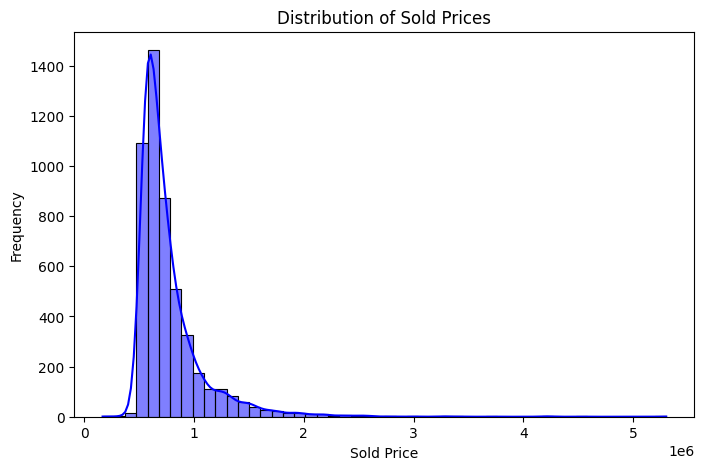

In [ ]:
# Distribution of Sold Prices
plt.figure(figsize=(8, 5))
sns.histplot(data['sold_price'], bins=50, kde=True, color='blue')
plt.title("Distribution of Sold Prices")
plt.xlabel("Sold Price")
plt.ylabel("Frequency")
plt.show()

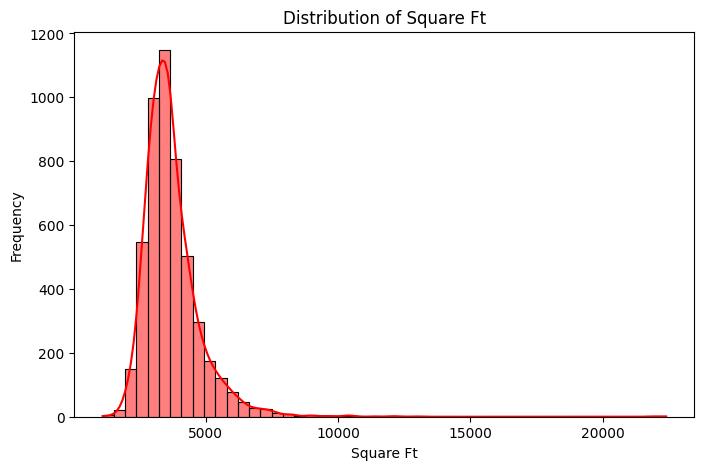

In [ ]:
# Distribution of Square Ft
plt.figure(figsize=(8, 5))
sns.histplot(data['sqrt_ft'], bins=50, kde=True, color='red')
plt.title("Distribution of Square Ft")
plt.xlabel("Square Ft")
plt.ylabel("Frequency")
plt.show()

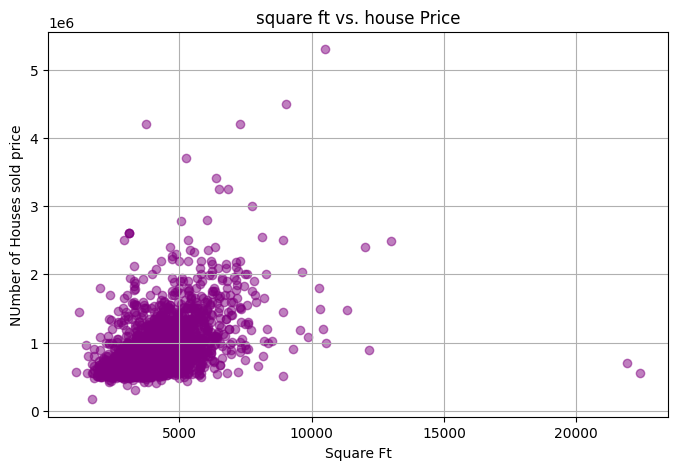

In [ ]:
# Relationship between Square Footage and Sold Price

plt.figure(figsize=(8, 5))
plt.scatter(data['sqrt_ft'], data['sold_price'], alpha=0.5, color='purple')
plt.xlabel("Square Ft")
plt.ylabel("NUmber of Houses sold price")
plt.title("square ft vs. house Price")
plt.grid(True)
plt.show()

datetime64[ns]


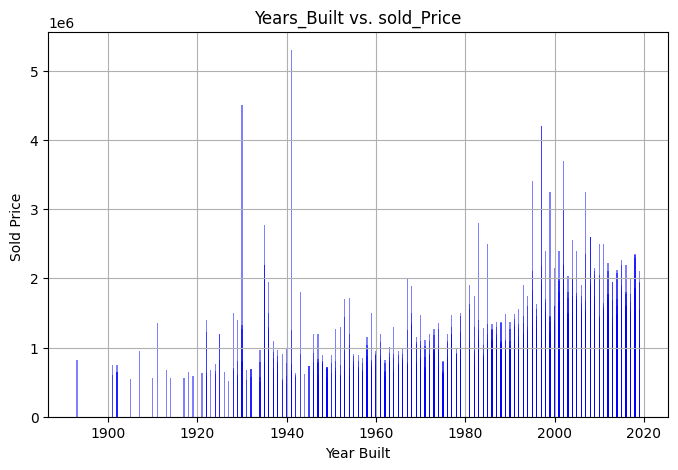

In [ ]:
'''
sns.countplot(x='year_built', hue='sold_price', data=data)
plt.title("Price rate over the years")
plt.show()
'''

# Replace "0" with NaN
data['year_built'] = data['year_built'].replace("0", np.nan)

# Convert to datetime (handling NaN)
data['year_built'] = pd.to_datetime(data['year_built'], format='%Y', errors='coerce')
#Printing data type of year_built
print(data['year_built'].dtype)
plt.figure(figsize=(8, 5))
plt.bar(data['year_built'], data['sold_price'], alpha=0.5, color='blue',width=100)
plt.xlabel("Year Built")
plt.ylabel("Sold Price ")
plt.title("Years_Built vs. sold_Price")
plt.grid(True)
plt.show()


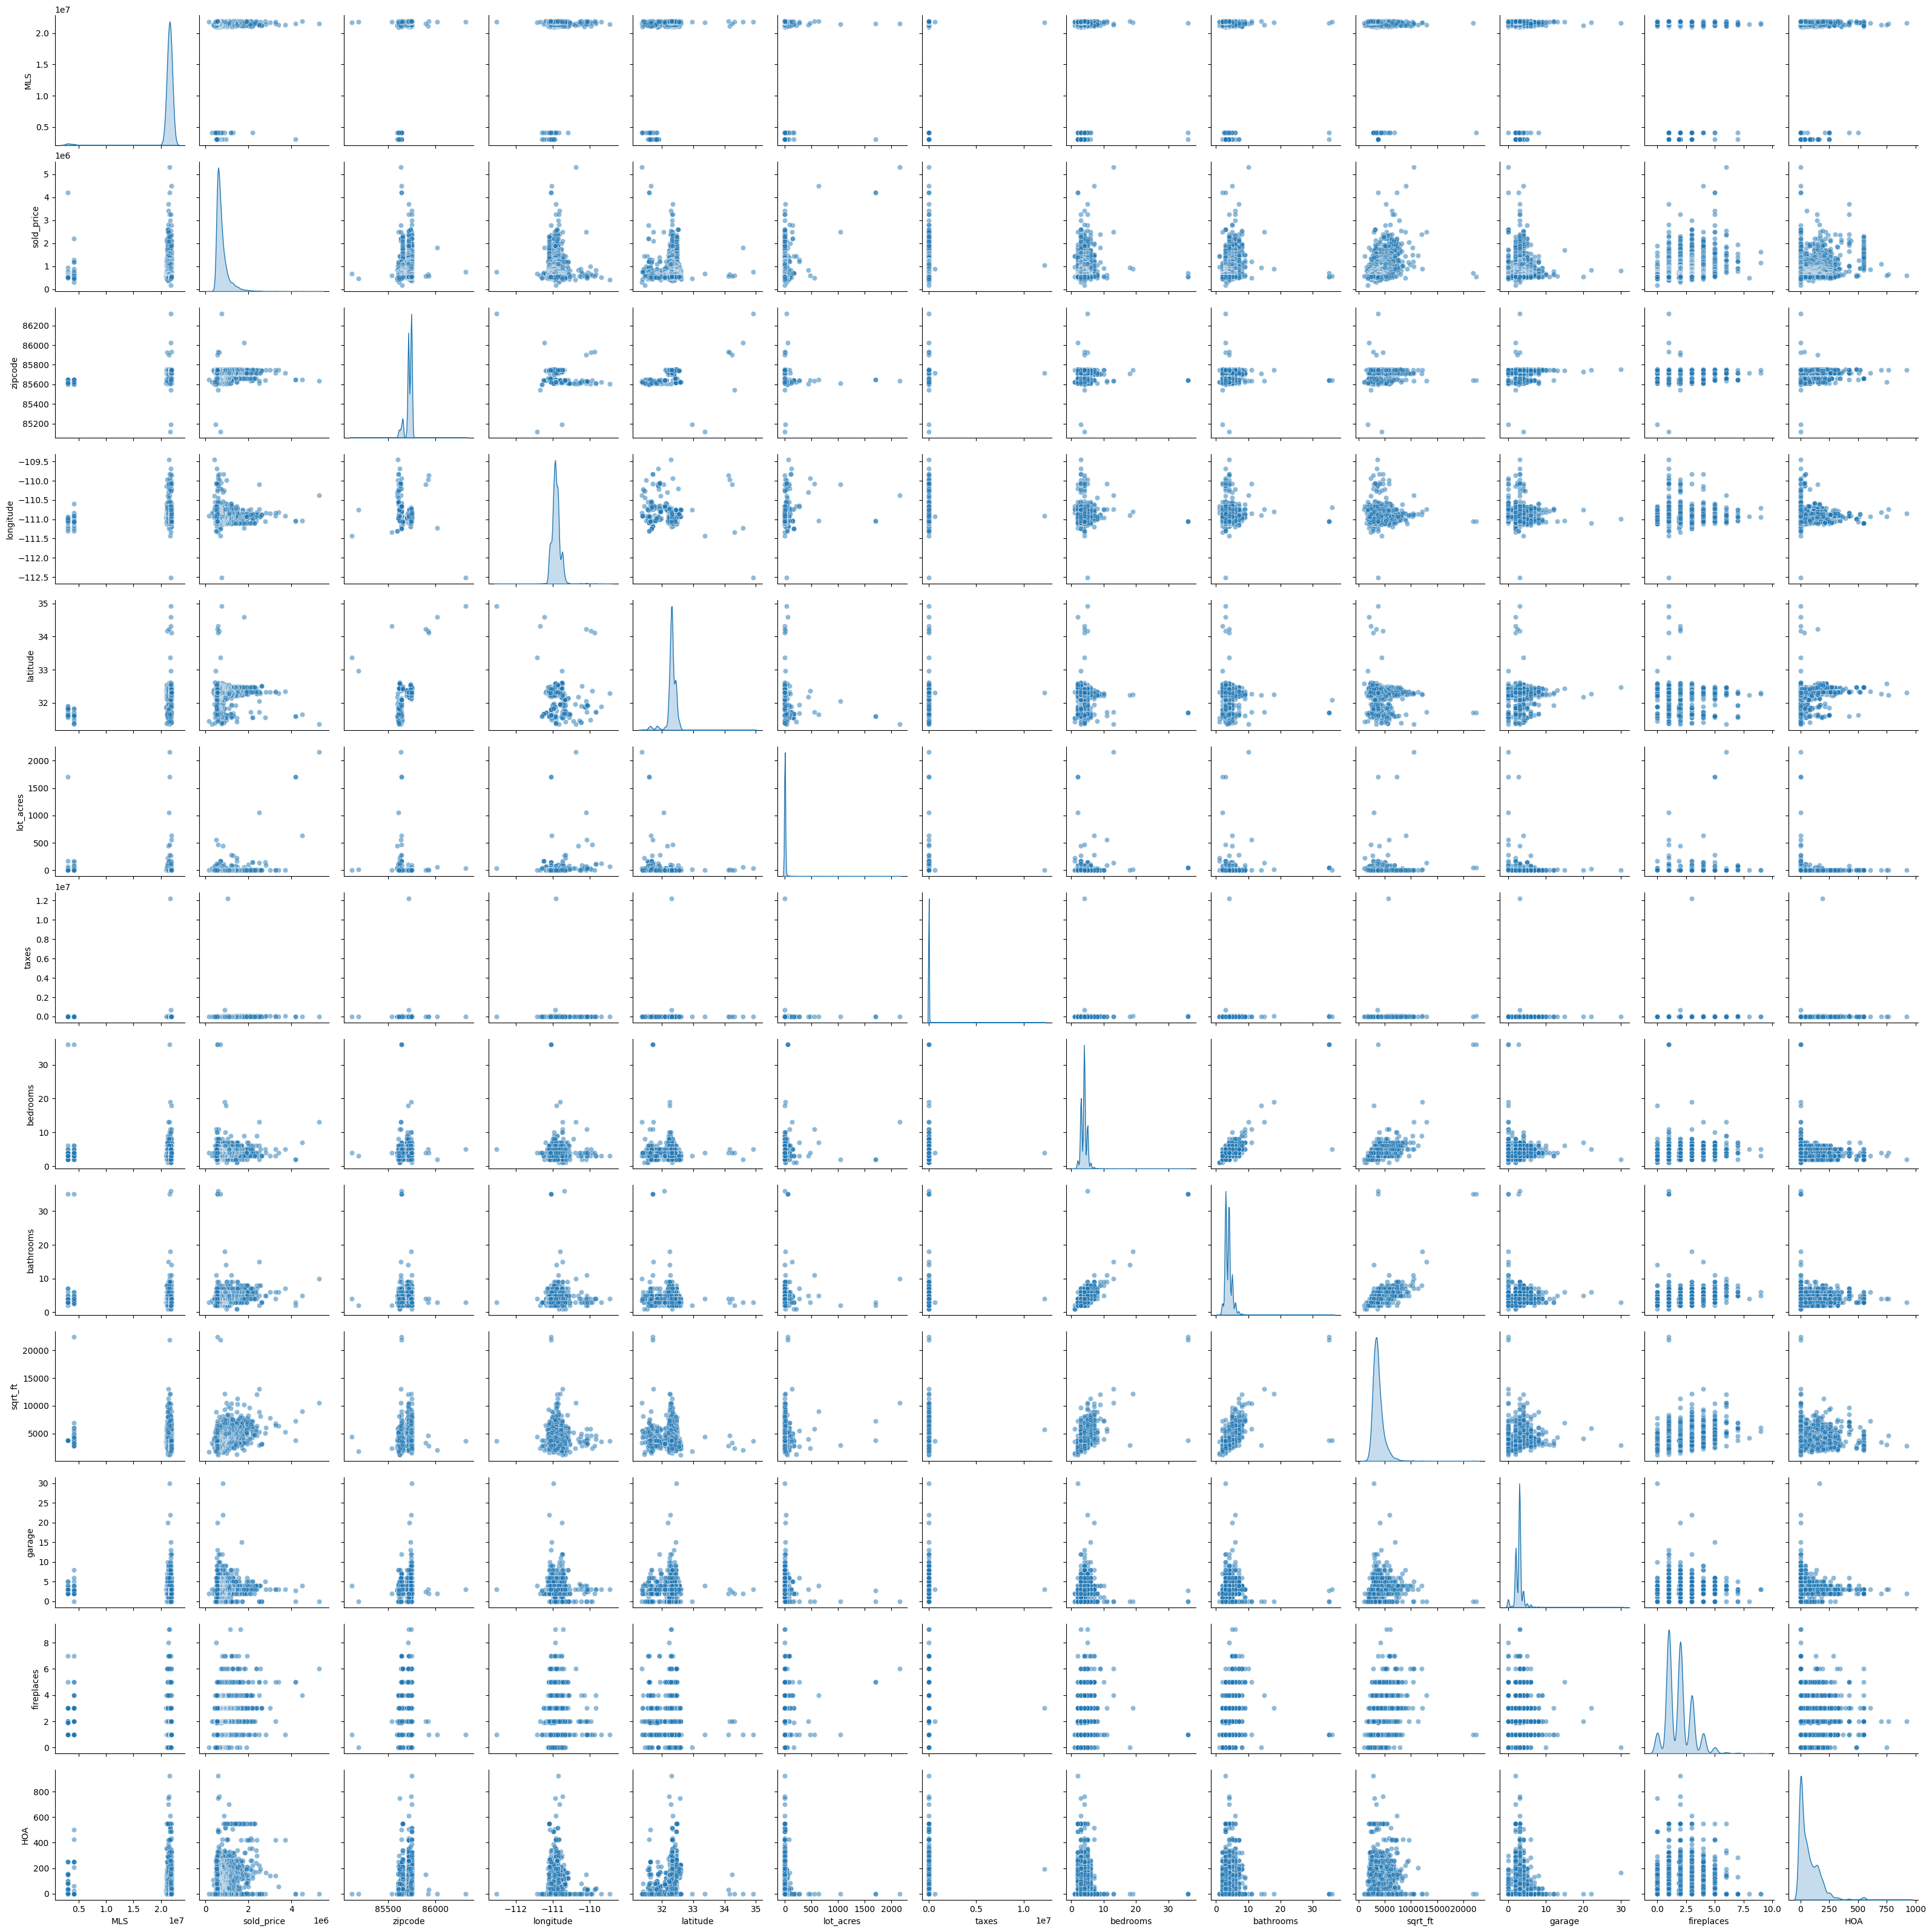

In [ ]:
# Generate Pair Plots
sns.pairplot(data, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

In [ ]:
# Function to count outliers
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers)

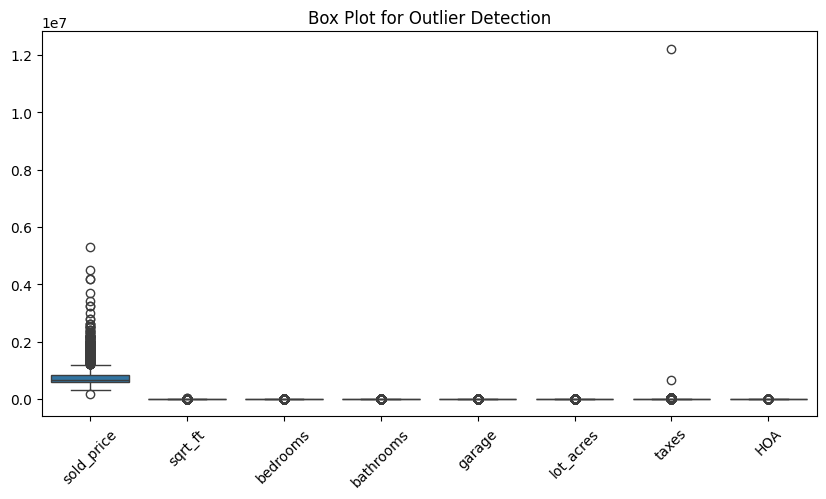

In [ ]:
#Detect Outliers using Box-and-Whisker Plots
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[['sold_price', 'sqrt_ft', 'bedrooms', 'bathrooms', 'garage', 'lot_acres', 'taxes','HOA']])
plt.xticks(rotation=45)
plt.title("Box Plot for Outlier Detection")
plt.show()

In [ ]:
#Counting the number outliers in each numerical feature
numerical_features = ['sold_price', 'sqrt_ft', 'bedrooms', 'bathrooms', 'garage', 'lot_acres', 'taxes', 'HOA']
outlier_counts = {col: count_outliers(data, col) for col in numerical_features}

In [ ]:
# Find the feature with the most outliers
most_outliers_feature = max(outlier_counts, key=outlier_counts.get)
print(most_outliers_feature)

lot_acres


In [ ]:
#Printing the number of outliers in each numeric feature
print(outlier_counts)

{'sold_price': 388, 'sqrt_ft': 236, 'bedrooms': 173, 'bathrooms': 303, 'garage': 375, 'lot_acres': 575, 'taxes': 272, 'HOA': 98}


In [ ]:
#calculating the IQR and lower and upper bound range with most_outlier_feature:lot_acres
Q1 = data[most_outliers_feature].quantile(0.25)
Q3 = data[most_outliers_feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[~((data[most_outliers_feature] < lower_bound) | (data[most_outliers_feature] > upper_bound))]


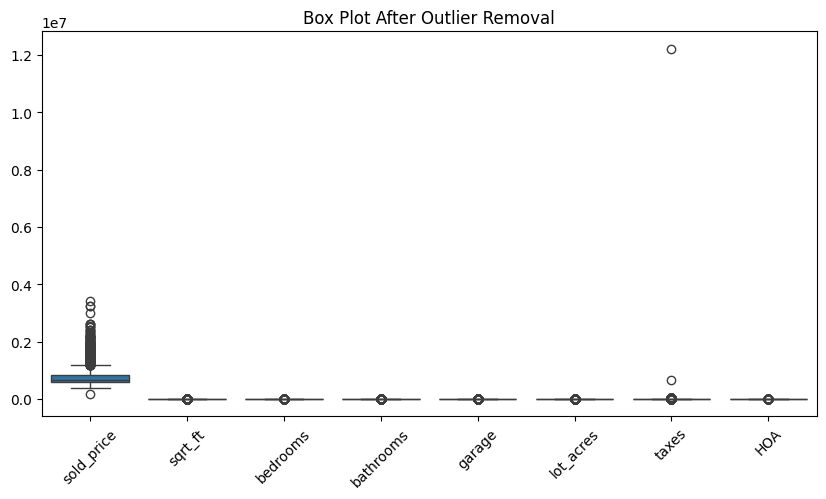

In [ ]:
# Replot the box plot after removing outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[['sold_price', 'sqrt_ft', 'bedrooms', 'bathrooms', 'garage', 'lot_acres', 'taxes', 'HOA']])
plt.xticks(rotation=45)
plt.title("Box Plot After Outlier Removal")
plt.show()


In [ ]:
#If 'kitchen_features' is not the only non-numeric column, include other relevant column names in the list
numeric_data = data.select_dtypes(include=np.number)

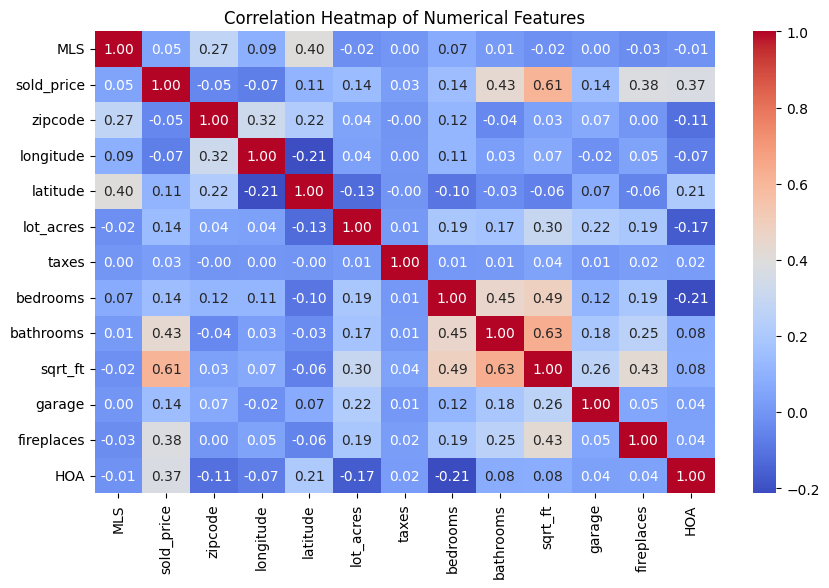

In [ ]:
# Correlation Heatmap
correlation = numeric_data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

###Feature Engineering : Create new features based on existing ones.

In [ ]:
#1. Creating price_per_sqft feature :  helps to normalize property prices based on size.
data['price_per_sqft'] = data['sold_price'] / data['sqrt_ft']

#2. tax_price_ratio feature : high property taxes can affect buyer's decisions of buying the house
data['tax_price_ratio'] = data['taxes'] / data['sold_price']

#3. Converts HOA into categories
def categorize_hoa(fee):
    if fee == 0:
        return "No HOA"
    elif fee <= 100:
        return "Low"
    elif fee <= 300:
        return "Medium"
    else:
        return "High"

data['HOA_category'] = data['HOA'].apply(categorize_hoa)

data.head(1)

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA,price_per_sqft,tax_price_ratio,HOA_category
4,21306357,3411450.0,85750,-110.813768,32.285162,3.21,15393.0,1995-01-01,4,6.0,6396.0,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5.0,"Carpet, Concrete",55.0,533.37242,0.004512,Low


### Saving the clean data after EDA as cleaned_house_data.csv

In [ ]:
# Save the cleaned dataset
data.to_csv("cleaned_house_data.csv", index=False)
print("Cleaned dataset saved as cleaned_house_data.csv")


Cleaned dataset saved as cleaned_house_data.csv
